In [1]:
# ===== AGENT 4: WEARABLE AGENT — IMPORTS + HEADER =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, interpolate, stats
from scipy.signal import lombscargle
from datetime import datetime, timedelta, timezone
from dataclasses import dataclass, field
from typing import Optional, Any
import uuid
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.size"] = 11

np.random.seed(42)

print("=" * 60)
print("IMMUNOSENSE — AGENT 4: WEARABLE AGENT")
print("=" * 60)
print("Purpose: Wearable signal -> 29-dim feature vector + alerts")
print("Cadence: hourly (8-hour patches accumulated for JEPA)")
print("Vector dim: 29 (HRV: 10, Sleep: 5, Temp: 2, Cardio: 3,")
print("              Activity: 2, Resp: 2, TADI: 2, Composite: 2, Quality: 1)")


IMMUNOSENSE — AGENT 4: WEARABLE AGENT
Purpose: Wearable signal -> 29-dim feature vector + alerts
Cadence: hourly (8-hour patches accumulated for JEPA)
Vector dim: 29 (HRV: 10, Sleep: 5, Temp: 2, Cardio: 3,
              Activity: 2, Resp: 2, TADI: 2, Composite: 2, Quality: 1)


## Cell 3 — Shared utilities (embedded)

Agent 4 owns its own copy of `RobustBaselineTracker` and `PatternDetector`.
These are identical in interface to Agent 1's versions, but live here independently.
Agents do not import each other — the Conductor mediates.

In [2]:
# ===== EMBEDDED: RobustBaselineTracker =====
# (identical to Agent 1's interface — duplicated here for agent isolation)

class RobustBaselineTracker:
    """Tracks personal baselines using rolling median + IQR.
    Outlier-resistant: flare/anomaly readings do not corrupt the baseline.

    Interface:
      .update(reading)                 # dict like {"hrv_rmssd_sleep": 32.5, ...}
      .get_personal_context(reading)   # returns nested dict (see below)
    """

    def __init__(self, features, window=10, outlier_threshold=2.0):
        self.features = features
        self.window = window
        self.outlier_threshold = outlier_threshold
        self.history = {f: [] for f in features}
        self.clean_history = {f: [] for f in features}
        self.n_readings = 0
        self.n_outliers_detected = {f: 0 for f in features}

    def update(self, reading):
        self.n_readings += 1
        for f in self.features:
            if f not in reading or reading[f] is None:
                continue
            value = reading[f]
            if not np.isfinite(value):
                continue
            self.history[f].append(value)

            if len(self.clean_history[f]) >= 3:
                median = np.median(self.clean_history[f][-self.window:])
                iqr = self._compute_iqr(self.clean_history[f][-self.window:])
                if iqr > 0:
                    anomaly = abs(value - median) / iqr
                    if anomaly > self.outlier_threshold:
                        self.n_outliers_detected[f] += 1
                        continue
            self.clean_history[f].append(value)

    @staticmethod
    def _compute_iqr(values):
        if len(values) < 4:
            return float(np.std(values)) if len(values) > 1 else 1.0
        return max(float(np.percentile(values, 75) - np.percentile(values, 25)), 0.01)

    def get_personal_context(self, reading):
        if self.n_readings < 3:
            return {
                "has_personal_data": False,
                "readings_count": self.n_readings,
                "personal_weight": 0.0,
            }

        ctx = {
            "has_personal_data": True,
            "readings_count": self.n_readings,
            "personal_weight": min(0.8, self.n_readings / 25),
            "biomarkers": {},
        }

        for f in self.features:
            if f not in reading or reading[f] is None:
                continue
            clean = self.clean_history[f]
            if len(clean) < 3:
                continue
            value = reading[f]
            recent = clean[-self.window:]
            median = float(np.median(recent))
            iqr = self._compute_iqr(recent)
            q25 = float(np.percentile(recent, 25))
            q75 = float(np.percentile(recent, 75))
            std = float(np.std(recent))

            anomaly_score = (value - median) / iqr if iqr > 0 else 0.0
            z_score = (value - median) / std if std > 0 else 0.0
            ratio = value / median if median > 0 else 0.0

            all_recent = self.history[f][-5:]
            if len(all_recent) >= 3:
                slope = float(np.polyfit(range(len(all_recent)), all_recent, 1)[0])
                trend = ("RISING" if slope > iqr * 0.05
                         else "FALLING" if slope < -iqr * 0.05
                         else "STABLE")
            else:
                trend = "UNKNOWN"

            if abs(anomaly_score) > 3:
                interp = "CRITICAL"
            elif abs(anomaly_score) > 2:
                interp = "ELEVATED" if value > median else "SUPPRESSED"
            elif abs(anomaly_score) > 1.2:
                interp = "MILDLY_ELEVATED" if value > median else "MILDLY_LOW"
            else:
                interp = "NORMAL"

            ctx["biomarkers"][f] = {
                "value": round(float(value), 3),
                "median_baseline": round(median, 3),
                "iqr": round(iqr, 3),
                "q25": round(q25, 3),
                "q75": round(q75, 3),
                "anomaly_score": round(anomaly_score, 2),
                "z_score": round(z_score, 2),
                "ratio": round(ratio, 3),
                "trend": trend,
                "interpretation": interp,
                "outliers_excluded": self.n_outliers_detected[f],
            }

        return ctx


# ===== EMBEDDED: PatternDetector =====

class PatternDetector:
    """Detects trigger-feature correlations across time lags."""

    def __init__(self, features, triggers, lag_range=(1, 3), min_readings=10):
        self.features = features
        self.triggers = triggers
        self.lag_range = lag_range
        self.min_readings = min_readings
        self.detected_patterns = []

    def analyze(self, trajectory):
        if len(trajectory) < self.min_readings:
            return {"has_patterns": False,
                    "message": f"Need {self.min_readings}+ readings"}
        self.detected_patterns = []

        for f in self.features:
            f_vals = [r.get(f) for r in trajectory]
            if any(v is None for v in f_vals):
                continue
            f_arr = np.array(f_vals)

            for trig in self.triggers:
                t_vals = [1 if r.get(trig, False) else 0 for r in trajectory]
                t_arr = np.array(t_vals)

                for lag in range(self.lag_range[0], self.lag_range[1] + 1):
                    if lag >= len(t_arr):
                        continue
                    t_shifted = t_arr[:-lag] if lag > 0 else t_arr
                    f_shifted = f_arr[lag:] if lag > 0 else f_arr
                    n = min(len(t_shifted), len(f_shifted))
                    if n < 5:
                        continue
                    t_shifted, f_shifted = t_shifted[:n], f_shifted[:n]
                    if t_shifted.std() == 0 or f_shifted.std() == 0:
                        continue
                    corr = float(np.corrcoef(t_shifted, f_shifted)[0, 1])

                    exposed = f_shifted[t_shifted == 1]
                    unexposed = f_shifted[t_shifted == 0]
                    if len(exposed) >= 2 and len(unexposed) >= 2:
                        effect_size = float(exposed.mean() - unexposed.mean())
                        effect_pct = (effect_size / unexposed.mean() * 100
                                      if unexposed.mean() != 0 else 0.0)
                    else:
                        effect_size = 0.0
                        effect_pct = 0.0

                    if abs(corr) > 0.25:
                        self.detected_patterns.append({
                            "trigger": trig,
                            "biomarker": f,
                            "lag_readings": lag,
                            "correlation": round(corr, 3),
                            "effect_size": round(effect_size, 3),
                            "effect_pct": round(effect_pct, 1),
                            "n_exposed": int(t_shifted.sum()),
                            "strength": "STRONG" if abs(corr) > 0.5 else "MODERATE",
                        })

        self.detected_patterns.sort(key=lambda x: abs(x["correlation"]), reverse=True)
        return {
            "has_patterns": len(self.detected_patterns) > 0,
            "patterns": self.detected_patterns,
            "n_readings_analyzed": len(trajectory),
        }


print("Shared utilities embedded:")
print("  - RobustBaselineTracker (rolling median + IQR, outlier-resistant)")
print("  - PatternDetector (trigger-feature lag correlations)")


Shared utilities embedded:
  - RobustBaselineTracker (rolling median + IQR, outlier-resistant)
  - PatternDetector (trigger-feature lag correlations)


## Cell 4 — BaseAgent contract

The shared interface every agent implements. The Conductor only talks to agents through this.
We design it here so Agent 4 can be the reference implementation.

In [3]:
# ===== BASEAGENT CONTRACT =====
# This is the universal interface every agent implements.
# Conductor only interacts with agents through this contract.

@dataclass
class AgentOutput:
    agent_id: str
    timestamp: datetime
    data: dict                  # agent-specific payload
    vector: np.ndarray          # fixed-size vector for JEPA
    vector_dim: int
    alerts: list                # threshold violations / named patterns
    confidence: float           # 0..1 data quality score
    trace_id: str


@dataclass
class AgentHealth:
    agent_id: str
    status: str                 # "healthy" | "degraded" | "down"
    last_heartbeat: datetime
    last_success: Optional[datetime]
    error_count_24hr: int
    avg_latency_ms: float


class BaseAgent:
    """Universal interface. Every agent inherits from this."""

    agent_id: str = "base"
    agent_version: str = "1.0.0"
    poll_frequency: str = "1hr"
    output_dim: int = 0

    def initialize(self, config: dict, mem0_client=None, trace_logger=None):
        self.config = config
        self.mem0 = mem0_client
        self.trace = trace_logger
        self._error_count = 0
        self._last_success: Optional[datetime] = None
        self._latencies: list = []

    def process(self, input_data: dict) -> AgentOutput:
        raise NotImplementedError

    def get_output_vector(self) -> np.ndarray:
        raise NotImplementedError

    def get_status(self) -> AgentHealth:
        avg_lat = float(np.mean(self._latencies[-100:])) if self._latencies else 0.0
        return AgentHealth(
            agent_id=self.agent_id,
            status=self._compute_status(),
            last_heartbeat=datetime.utcnow(),
            last_success=self._last_success,
            error_count_24hr=self._error_count,
            avg_latency_ms=avg_lat,
        )

    def _compute_status(self) -> str:
        if self._error_count > 10:
            return "down"
        if self._error_count > 3:
            return "degraded"
        return "healthy"

    def _new_trace_id(self) -> str:
        return f"{self.agent_id}-{uuid.uuid4().hex[:8]}"


print("BaseAgent contract defined.")
print(f"  AgentOutput fields: agent_id, timestamp, data, vector, vector_dim,")
print(f"                     alerts, confidence, trace_id")
print(f"  AgentHealth fields: agent_id, status, last_heartbeat, last_success,")
print(f"                     error_count_24hr, avg_latency_ms")


BaseAgent contract defined.
  AgentOutput fields: agent_id, timestamp, data, vector, vector_dim,
                     alerts, confidence, trace_id
  AgentHealth fields: agent_id, status, last_heartbeat, last_success,
                     error_count_24hr, avg_latency_ms


## Cell 5 — Mock wearable data generator

We don't have real wearable data yet (HealthKit/Fitbit/Oura come later).
Generate realistic minute-level streams using empirical distributions from
WESAD (HRV, EDA) and MESA (sleep architecture) literature.

The generator embeds **two flare patterns** so we can validate that the agent
catches them downstream:

1. **48-hour autoimmune prodrome**: HRV drops 30%, sleep efficiency drops,
   skin temp rises 0.4°C, TADI spikes (coupling breaks down)
2. **Acute stress response**: HRV drops sharply, resting HR rises, recovers in 24h


Normal night:
  Mean HR: 59.8 bpm
  Mean skin temp: 33.70 C
  Stage distribution: {'light': 278, 'deep': 104, 'rem': 93, 'wake': 5}
  RR intervals: 28469 beats

Prodrome night:
  Mean HR: 64.8 bpm (expect ~4 higher)
  Mean skin temp: 33.83 C (expect ~0.4 higher)
  RR intervals: 30875 beats (HRV reduced)


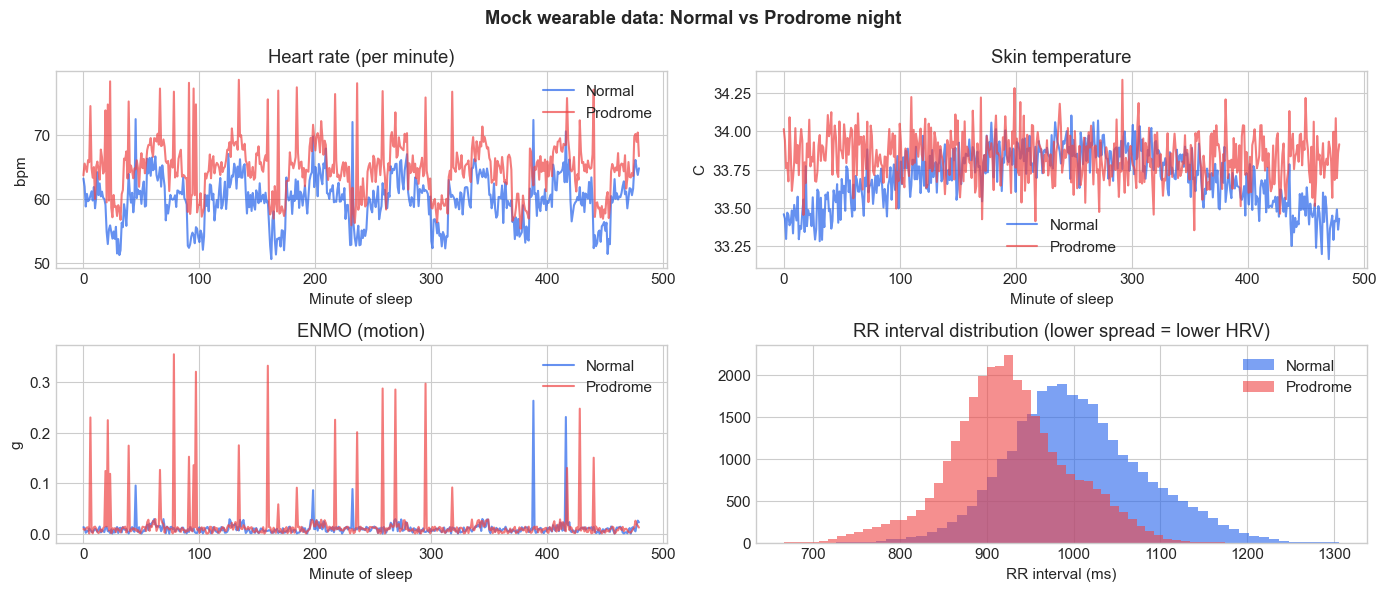

In [4]:
# ===== MOCK WEARABLE DATA GENERATOR =====
# Generates minute-level streams: HR, RR-intervals (HRV), skin temp,
# accelerometer, SpO2, sleep stages.
# Embeds known flare patterns for downstream validation.

class MockWearableGenerator:
    """Produces realistic minute-level wearable data with embedded flares."""

    # WESAD/MESA-derived population baselines
    BASELINE = {
        "resting_hr": 62.0,        # bpm
        "rr_interval": 950.0,       # ms (RR = 60000 / HR roughly)
        "hrv_rmssd": 45.0,          # ms during sleep
        "skin_temp": 33.5,          # degrees C overnight
        "spo2": 97.5,               # %
        "sleep_efficiency": 0.87,   # fraction
    }

    def __init__(self, patient_id="p001", seed=42):
        self.patient_id = patient_id
        self.rng = np.random.default_rng(seed)
        # Personal offsets (small shifts from population mean — fixed per patient)
        self.personal = {
            "resting_hr": self.BASELINE["resting_hr"] + self.rng.normal(0, 4),
            "hrv_rmssd_base": self.BASELINE["hrv_rmssd"] + self.rng.normal(0, 5),
            "skin_temp_base": self.BASELINE["skin_temp"] + self.rng.normal(0, 0.1),
        }

    def _nightly_jitter(self):
        """Re-jitter the personal baseline each night.

        Real human biology has natural inter-night variability — same person,
        same sensor, naturally varies by a few ms / bpm / 0.1 C from one night
        to the next. Without this, baseline IQR collapses to near-zero and
        anomaly scores explode on flare nights.
        """
        return {
            "hrv": float(self.rng.normal(0, 4.0)),       # ~4 ms inter-night variance
            "hr": float(self.rng.normal(0, 1.5)),         # ~1.5 bpm inter-night variance
            "skin_temp": float(self.rng.normal(0, 0.15)), # ~0.15 C inter-night variance
        }

    def generate_night(self, night_idx: int, flare_state: str = "normal",
                       start_time: datetime = None):
        """Generate one night of minute-level data (8 hours = 480 minutes).

        flare_state: 'normal' | 'prodrome' | 'acute_stress'
        Returns a DataFrame indexed by timestamp.
        """
        if start_time is None:
            start_time = datetime(2026, 4, 1, 23, 0, 0, tzinfo=timezone.utc) + \
                         timedelta(days=night_idx)
        n_minutes = 480  # 8 hours

        # ---- Per-night biological jitter ----
        jitter = self._nightly_jitter()

        # ---- Flare modifiers ----
        if flare_state == "prodrome":
            hrv_multiplier = 0.70           # 30% HRV drop
            sleep_quality_mult = 0.85       # poorer sleep
            temp_offset = 0.4               # 0.4 C elevation
            tadi_decouple = True            # break HRV-temp coupling
            hr_offset = 4
        elif flare_state == "acute_stress":
            hrv_multiplier = 0.65
            sleep_quality_mult = 0.75
            temp_offset = 0.1
            tadi_decouple = False
            hr_offset = 8
        else:
            hrv_multiplier = 1.0
            sleep_quality_mult = 1.0
            temp_offset = 0.0
            tadi_decouple = False
            hr_offset = 0

        # ---- Sleep stages (Cole-Kripke-ish; light/deep/REM/wake) ----
        # Realistic sleep architecture: ~50% light, ~20% deep (early), ~25% REM (late), ~5% wake
        stages = self._simulate_sleep_stages(n_minutes, sleep_quality_mult)

        # ---- Heart rate (minute-level) — adds nightly HR jitter ----
        # Drops during deep sleep, rises during REM, stable during light
        hr = np.full(n_minutes, self.personal["resting_hr"] + hr_offset + jitter["hr"])
        hr += self.rng.normal(0, 1.5, n_minutes)  # baseline noise within night
        for i, st in enumerate(stages):
            if st == "deep":
                hr[i] -= 6
            elif st == "rem":
                hr[i] += 4
            elif st == "wake":
                hr[i] += 12
        hr = np.maximum(hr, 35.0)

        # ---- RR intervals derived from HR (60000 / HR + HRV noise) ----
        # HRV controls the noise scale on RR intervals — adds nightly HRV jitter
        rr_intervals = []
        hrv_per_minute = (self.personal["hrv_rmssd_base"] + jitter["hrv"]) * hrv_multiplier
        hrv_per_minute = max(hrv_per_minute, 5.0)  # floor — HRV can't go to zero
        for i in range(n_minutes):
            n_beats = max(int(hr[i]), 30)
            mean_rr = 60000.0 / hr[i]
            rr = self.rng.normal(mean_rr, hrv_per_minute, n_beats)
            rr = np.maximum(rr, 300)  # physiological floor
            rr_intervals.extend(rr.tolist())

        # ---- Skin temperature — adds nightly skin temp jitter ----
        # Normally rises during sleep (heat dumping via vasodilation)
        # If TADI-decoupled (prodrome), temp stays elevated/flat instead of cycling
        time_hours = np.arange(n_minutes) / 60.0
        base_temp = self.personal["skin_temp_base"] + temp_offset + jitter["skin_temp"]
        if tadi_decouple:
            # Temp stays elevated, doesn't follow the normal cycle
            skin_temp = base_temp + self.rng.normal(0, 0.15, n_minutes)
        else:
            # Normal cycle: gentle rise from sleep onset, peak ~mid-sleep
            skin_temp_pattern = 0.5 * np.sin(np.pi * time_hours / 8.0)
            skin_temp = (base_temp + skin_temp_pattern +
                         self.rng.normal(0, 0.1, n_minutes))

        # ---- Accelerometer (ENMO) ----
        # Low during sleep, brief spikes during awake/turning
        enmo = np.full(n_minutes, 0.01)
        for i, st in enumerate(stages):
            if st == "wake":
                enmo[i] = self.rng.uniform(0.05, 0.4)
            elif st == "rem":
                enmo[i] = self.rng.uniform(0.005, 0.03)
            else:
                enmo[i] = self.rng.uniform(0.001, 0.015)

        # ---- SpO2 ----
        spo2 = np.full(n_minutes, self.BASELINE["spo2"]) + \
               self.rng.normal(0, 0.4, n_minutes)
        # Occasional dips during REM
        for i, st in enumerate(stages):
            if st == "rem" and self.rng.random() < 0.02:
                spo2[i] -= self.rng.uniform(2, 5)
        spo2 = np.clip(spo2, 80, 100)

        # ---- Build DataFrame ----
        timestamps = [start_time + timedelta(minutes=i) for i in range(n_minutes)]
        df = pd.DataFrame({
            "timestamp": timestamps,
            "hr": hr,
            "skin_temp": skin_temp,
            "enmo": enmo,
            "spo2": spo2,
            "sleep_stage": stages,
        })

        return df, rr_intervals

    def _simulate_sleep_stages(self, n_minutes, quality_mult):
        """Produce a realistic sleep-stage sequence."""
        stages = []
        # Rough cycle: light(20) -> deep(15) -> light(20) -> rem(15), repeat ~5 cycles
        cycle_template = (["light"] * 20 + ["deep"] * 15 + ["light"] * 20 + ["rem"] * 15)
        while len(stages) < n_minutes:
            stages.extend(cycle_template)
        stages = stages[:n_minutes]

        # Inject wake periods (poor sleep quality = more wake)
        wake_rate = (1.0 - quality_mult) * 0.15 + 0.02
        for i in range(n_minutes):
            if self.rng.random() < wake_rate:
                stages[i] = "wake"

        return stages


# ===== TEST: generate a normal night and a prodrome night =====
gen = MockWearableGenerator(patient_id="p001", seed=42)
night_normal, rr_normal = gen.generate_night(0, flare_state="normal")
night_prodrome, rr_prodrome = gen.generate_night(1, flare_state="prodrome")

print(f"Normal night:")
print(f"  Mean HR: {night_normal['hr'].mean():.1f} bpm")
print(f"  Mean skin temp: {night_normal['skin_temp'].mean():.2f} C")
print(f"  Stage distribution: {night_normal['sleep_stage'].value_counts().to_dict()}")
print(f"  RR intervals: {len(rr_normal)} beats")
print()
print(f"Prodrome night:")
print(f"  Mean HR: {night_prodrome['hr'].mean():.1f} bpm (expect ~4 higher)")
print(f"  Mean skin temp: {night_prodrome['skin_temp'].mean():.2f} C (expect ~0.4 higher)")
print(f"  RR intervals: {len(rr_prodrome)} beats (HRV reduced)")

# Quick visual check
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes[0, 0].plot(night_normal["hr"].values, color="#2563eb", label="Normal", alpha=0.7)
axes[0, 0].plot(night_prodrome["hr"].values, color="#ef4444", label="Prodrome", alpha=0.7)
axes[0, 0].set_title("Heart rate (per minute)")
axes[0, 0].set_xlabel("Minute of sleep"); axes[0, 0].set_ylabel("bpm")
axes[0, 0].legend()

axes[0, 1].plot(night_normal["skin_temp"].values, color="#2563eb", label="Normal", alpha=0.7)
axes[0, 1].plot(night_prodrome["skin_temp"].values, color="#ef4444", label="Prodrome", alpha=0.7)
axes[0, 1].set_title("Skin temperature")
axes[0, 1].set_xlabel("Minute of sleep"); axes[0, 1].set_ylabel("C")
axes[0, 1].legend()

axes[1, 0].plot(night_normal["enmo"].values, color="#2563eb", label="Normal", alpha=0.7)
axes[1, 0].plot(night_prodrome["enmo"].values, color="#ef4444", label="Prodrome", alpha=0.7)
axes[1, 0].set_title("ENMO (motion)")
axes[1, 0].set_xlabel("Minute of sleep"); axes[1, 0].set_ylabel("g")
axes[1, 0].legend()

axes[1, 1].hist(rr_normal, bins=50, alpha=0.6, color="#2563eb", label="Normal")
axes[1, 1].hist(rr_prodrome, bins=50, alpha=0.6, color="#ef4444", label="Prodrome")
axes[1, 1].set_title("RR interval distribution (lower spread = lower HRV)")
axes[1, 1].set_xlabel("RR interval (ms)")
axes[1, 1].legend()

fig.suptitle("Mock wearable data: Normal vs Prodrome night", fontweight="bold")
plt.tight_layout()
plt.show()

## Cell 6 — Layer 2: Preprocessing

Three techniques per architecture v6:
- **Incremental Hampel filter** — streaming O(log W) artifact removal for RR intervals
- **Akima spline** — overshoot-free gap filling for sharp physiological transitions
- **ENMO + variance threshold** — sleep/wake refinement from accelerometer


In [5]:
# ===== LAYER 2: PREPROCESSING =====

class HampelFilter:
    """Sliding-window Hampel filter for artifact removal.
    Replaces points whose deviation > k*MAD from local median.
    """

    def __init__(self, window_size: int = 7, k_threshold: float = 3.0):
        self.window_size = window_size
        self.k = k_threshold

    def filter(self, values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Returns (filtered_values, outlier_mask)."""
        values = np.asarray(values, dtype=float)
        n = len(values)
        out = values.copy()
        mask = np.zeros(n, dtype=bool)
        w = self.window_size // 2

        for i in range(n):
            lo, hi = max(0, i - w), min(n, i + w + 1)
            window = values[lo:hi]
            med = np.median(window)
            mad = 1.4826 * np.median(np.abs(window - med))
            if mad > 0 and abs(values[i] - med) > self.k * mad:
                out[i] = med
                mask[i] = True
        return out, mask


def akima_interpolate(timestamps_min: np.ndarray, values: np.ndarray,
                       target_min: np.ndarray) -> np.ndarray:
    """Akima 1-D spline interpolation. No overshoot at sharp transitions."""
    valid = np.isfinite(values)
    if valid.sum() < 4:
        return np.interp(target_min, timestamps_min[valid], values[valid])
    spline = interpolate.Akima1DInterpolator(timestamps_min[valid], values[valid])
    return spline(target_min)


def enmo_sleep_wake(enmo: np.ndarray, hr: np.ndarray,
                     enmo_var_window: int = 5,
                     enmo_var_threshold: float = 1e-4,
                     hr_threshold: float = 75.0) -> np.ndarray:
    """Classify each minute as 'sleep' or 'wake' from ENMO + HR.

    Rule: if 5-min rolling ENMO variance is below threshold AND HR is reasonable
    for sleep, label as 'sleep'. Otherwise 'wake'.
    """
    n = len(enmo)
    labels = np.empty(n, dtype="<U5")
    for i in range(n):
        lo, hi = max(0, i - enmo_var_window // 2), min(n, i + enmo_var_window // 2 + 1)
        var = float(np.var(enmo[lo:hi]))
        if var < enmo_var_threshold and hr[i] < hr_threshold:
            labels[i] = "sleep"
        else:
            labels[i] = "wake"
    return labels


# ===== TEST L2 on the prodrome night =====
print("Testing L2 preprocessing on prodrome night...")

# Apply Hampel to RR intervals (the noisiest signal)
hampel = HampelFilter(window_size=11, k_threshold=3.0)
rr_arr = np.array(rr_prodrome)
rr_clean, rr_outlier_mask = hampel.filter(rr_arr)

print(f"  Hampel: {rr_outlier_mask.sum()} of {len(rr_arr)} RR intervals "
      f"flagged as artifacts ({rr_outlier_mask.mean()*100:.2f}%)")

# Apply ENMO sleep/wake to the night
labels = enmo_sleep_wake(night_prodrome["enmo"].values, night_prodrome["hr"].values)
print(f"  ENMO sleep/wake: {(labels == 'sleep').sum()} sleep mins, "
      f"{(labels == 'wake').sum()} wake mins")

# Test Akima on a synthetic signal with a gap
ts = np.arange(20).astype(float)
vals = np.array([60, 61, 62, 63, np.nan, np.nan, np.nan, 80, 81, 82,
                 83, 82, 81, 80, 79, 78, 77, 76, 75, 74])
filled = akima_interpolate(ts, vals, ts)
print(f"  Akima: filled {np.isnan(vals).sum()} missing points, "
      f"min={filled.min():.1f}, max={filled.max():.1f}")
print(f"        (note: no overshoot beyond actual data range)")


Testing L2 preprocessing on prodrome night...
  Hampel: 910 of 30875 RR intervals flagged as artifacts (2.95%)
  ENMO sleep/wake: 375 sleep mins, 105 wake mins
  Akima: filled 3 missing points, min=60.0, max=83.0
        (note: no overshoot beyond actual data range)


## Cell 7 — Layer 3: Feature engineering (29 features)

Produces one feature dict per night-summary. The 29 features:

- HRV (10): rmssd_24hr, rmssd_sleep, rmssd_deep_sleep, sdnn, pnn50, hf_power, lf_hf_ratio, sleep_vs_baseline_ratio, trend_6hr, anomaly_score
- Sleep (5): duration_hrs, deep_pct, rem_pct, efficiency, vs_baseline
- Temp (2): deviation, trend_3day
- Cardio (3): resting_hr, vs_baseline, recovery_1min
- Activity (2): steps_24hr, vs_baseline
- Respiratory (2): spo2_overnight_min, spo2_dips_count
- TADI (2): index, vs_baseline
- Composite (2): wearable_stress_score, composite_alert_count
- Quality (1): data_quality_overall


In [6]:
# ===== LAYER 3: FEATURE ENGINEERING =====
# Canonical 29-feature list (order matters — this is the vector layout)

FEATURE_NAMES = [
    # HRV (10)
    "hrv_rmssd_24hr", "hrv_rmssd_sleep", "hrv_rmssd_deep_sleep", "hrv_sdnn",
    "hrv_pnn50", "hrv_hf_power", "hrv_lf_hf_ratio", "hrv_sleep_vs_baseline_ratio",
    "hrv_trend_6hr", "hrv_anomaly_score",
    # Sleep (5)
    "sleep_duration_hrs", "sleep_deep_pct", "sleep_rem_pct",
    "sleep_efficiency", "sleep_vs_baseline",
    # Temp (2)
    "skin_temp_deviation", "skin_temp_trend_3day",
    # Cardio (3)
    "resting_hr", "resting_hr_vs_baseline", "hr_recovery_1min",
    # Activity (2)
    "activity_steps_24hr", "activity_vs_baseline",
    # Respiratory (2)
    "spo2_overnight_min", "spo2_dips_count",
    # TADI (2)
    "thermo_autonomic_decoupling_index", "tadi_vs_baseline",
    # Composite (2)
    "wearable_stress_score", "composite_alert_count",
    # Quality (1)
    "data_quality_overall",
]
assert len(FEATURE_NAMES) == 29, f"Expected 29 features, got {len(FEATURE_NAMES)}"


def compute_hrv_features(rr_intervals: np.ndarray) -> dict:
    """Compute HRV time-domain + frequency-domain + non-linear features
    from a list of RR intervals (ms).
    """
    rr = np.asarray(rr_intervals, dtype=float)
    rr = rr[np.isfinite(rr) & (rr > 300) & (rr < 2000)]
    if len(rr) < 30:
        return {"rmssd": np.nan, "sdnn": np.nan, "pnn50": np.nan,
                "hf_power": np.nan, "lf_hf_ratio": np.nan,
                "sd1": np.nan, "sd2": np.nan}

    diffs = np.diff(rr)
    rmssd = float(np.sqrt(np.mean(diffs ** 2)))
    sdnn = float(np.std(rr))
    pnn50 = float(100.0 * np.mean(np.abs(diffs) > 50))

    # Frequency domain via Lomb-Scargle (handles irregular RR sampling)
    # Cumulative time of each beat
    t = np.cumsum(rr) / 1000.0  # seconds
    freqs = np.linspace(0.04, 0.4, 200)
    angular = 2 * np.pi * freqs
    try:
        psd = lombscargle(t, rr - rr.mean(), angular, normalize=True)
        lf_mask = (freqs >= 0.04) & (freqs < 0.15)
        hf_mask = (freqs >= 0.15) & (freqs < 0.40)
        lf_power = float(np.trapezoid(psd[lf_mask], freqs[lf_mask]))
        hf_power = float(np.trapezoid(psd[hf_mask], freqs[hf_mask]))
        lf_hf_ratio = lf_power / hf_power if hf_power > 1e-9 else np.nan
    except Exception:
        hf_power, lf_hf_ratio = np.nan, np.nan

    # Poincare SD1, SD2
    sd1 = float(np.std(diffs) / np.sqrt(2))
    sd2 = float(np.sqrt(2 * sdnn ** 2 - sd1 ** 2)) if sdnn ** 2 > sd1 ** 2 / 2 else np.nan

    return {"rmssd": rmssd, "sdnn": sdnn, "pnn50": pnn50,
            "hf_power": hf_power, "lf_hf_ratio": lf_hf_ratio,
            "sd1": sd1, "sd2": sd2}


def compute_sleep_features(stages: np.ndarray) -> dict:
    """Sleep architecture features from per-minute stage labels."""
    n = len(stages)
    if n == 0:
        return {"duration_hrs": np.nan, "deep_pct": np.nan,
                "rem_pct": np.nan, "efficiency": np.nan}
    asleep = np.isin(stages, ["light", "deep", "rem"]).sum()
    deep = (stages == "deep").sum()
    rem = (stages == "rem").sum()
    return {
        "duration_hrs": asleep / 60.0,
        "deep_pct": deep / max(asleep, 1),
        "rem_pct": rem / max(asleep, 1),
        "efficiency": asleep / n,
    }


def compute_tadi(hrv_curve: np.ndarray, temp_curve: np.ndarray,
                  min_samples: int = 30) -> float:
    """Thermo-Autonomic Decoupling Index.

    Computes lagged Pearson correlation between HRV and temp curves over sleep,
    z-scored within night. TADI = 1 - max(0, peak_correlation).
    Range: 0 (perfect coupling) to 1 (full decoupling).
    """
    if len(hrv_curve) < min_samples or len(temp_curve) < min_samples:
        return np.nan

    # Align lengths
    n = min(len(hrv_curve), len(temp_curve))
    hrv = hrv_curve[:n]
    temp = temp_curve[:n]

    # Z-score within night
    if np.std(hrv) < 1e-9 or np.std(temp) < 1e-9:
        return np.nan
    hrv_z = (hrv - np.mean(hrv)) / np.std(hrv)
    temp_z = (temp - np.mean(temp)) / np.std(temp)

    # Lagged correlation, lags in [-15, +30] minutes
    best_corr = -1.0
    for lag in range(-15, 31):
        if lag < 0:
            a, b = hrv_z[-lag:], temp_z[:lag]
        elif lag > 0:
            a, b = hrv_z[:-lag], temp_z[lag:]
        else:
            a, b = hrv_z, temp_z
        if len(a) < 10:
            continue
        c = float(np.corrcoef(a, b)[0, 1])
        if not np.isnan(c) and c > best_corr:
            best_corr = c

    return float(1.0 - max(0.0, best_corr))


def engineer_features(night_df: pd.DataFrame, rr_intervals: list,
                       night_idx: int) -> dict:
    """Produce a 29-feature reading dict from one night of data."""
    rr = np.array(rr_intervals)

    # Stage-filtered RR intervals
    # We need to map each RR interval to a sleep stage. For simplicity here,
    # assume RR intervals are roughly time-ordered within the night and use
    # the minute-level stage labels.
    n_minutes = len(night_df)
    stage_at_minute = night_df["sleep_stage"].values

    # Sleep-only and deep-sleep-only RR sets (heuristic: split RRs across minutes)
    beats_per_min = max(int(len(rr) / n_minutes), 1)
    rr_sleep, rr_deep = [], []
    for i, st in enumerate(stage_at_minute):
        beats_this_min = rr[i * beats_per_min:(i + 1) * beats_per_min]
        if st in ("light", "deep", "rem"):
            rr_sleep.extend(beats_this_min)
        if st == "deep":
            rr_deep.extend(beats_this_min)

    hrv_all = compute_hrv_features(rr)
    hrv_sleep = compute_hrv_features(np.array(rr_sleep))
    hrv_deep = compute_hrv_features(np.array(rr_deep))

    sleep = compute_sleep_features(stage_at_minute)

    # Resting HR: p10 of sleep-period HR
    sleep_mask = np.isin(stage_at_minute, ["light", "deep", "rem"])
    sleep_hr = night_df.loc[sleep_mask, "hr"].values
    resting_hr = float(np.percentile(sleep_hr, 10)) if len(sleep_hr) > 0 else np.nan

    # Skin temp deviation from a fixed reference (33.5 = healthy adult overnight median)
    overnight_temp = float(np.median(night_df.loc[sleep_mask, "skin_temp"].values)) \
                     if sleep_mask.any() else np.nan
    skin_temp_deviation = overnight_temp - 33.5 if not np.isnan(overnight_temp) else np.nan

    # SpO2 features
    overnight_spo2 = night_df.loc[sleep_mask, "spo2"].values
    spo2_min = float(np.percentile(overnight_spo2, 5)) if len(overnight_spo2) > 0 else np.nan
    spo2_dips = int(np.sum(np.diff(overnight_spo2) < -3)) if len(overnight_spo2) > 1 else 0

    # TADI: HRV curve and temp curve over sleep period (1-min resolution)
    # Approximate HRV per minute as rolling RMSSD of nearby RR intervals
    hrv_per_minute = []
    for i in range(n_minutes):
        window_rr = rr[max(0, i - 2) * beats_per_min:(i + 3) * beats_per_min]
        if len(window_rr) >= 10:
            diffs = np.diff(window_rr)
            hrv_per_minute.append(float(np.sqrt(np.mean(diffs ** 2))))
        else:
            hrv_per_minute.append(np.nan)
    hrv_curve = np.array(hrv_per_minute)
    temp_curve = night_df["skin_temp"].values
    # Restrict to sleep minutes
    hrv_curve = hrv_curve[sleep_mask]
    temp_curve = temp_curve[sleep_mask]
    tadi = compute_tadi(hrv_curve, temp_curve)

    # Data quality: fraction of expected features that we actually computed
    expected = [hrv_sleep["rmssd"], hrv_deep["rmssd"], sleep["duration_hrs"],
                skin_temp_deviation, resting_hr, spo2_min, tadi]
    coverage = float(np.mean([1.0 if not np.isnan(v) else 0.0 for v in expected]))

    # ---- Build the 29-feature reading dict ----
    reading = {
        "hour": night_idx,
        "timestamp": night_df["timestamp"].iloc[0].isoformat(),

        # HRV (10) — leave personal-normalized ones None initially
        "hrv_rmssd_24hr": hrv_all["rmssd"],
        "hrv_rmssd_sleep": hrv_sleep["rmssd"],
        "hrv_rmssd_deep_sleep": hrv_deep["rmssd"],
        "hrv_sdnn": hrv_sleep["sdnn"],
        "hrv_pnn50": hrv_sleep["pnn50"],
        "hrv_hf_power": hrv_sleep["hf_power"],
        "hrv_lf_hf_ratio": hrv_sleep["lf_hf_ratio"],
        "hrv_sleep_vs_baseline_ratio": None,  # filled by L4
        "hrv_trend_6hr": None,                # filled by L4
        "hrv_anomaly_score": None,            # filled by L4

        # Sleep (5)
        "sleep_duration_hrs": sleep["duration_hrs"],
        "sleep_deep_pct": sleep["deep_pct"],
        "sleep_rem_pct": sleep["rem_pct"],
        "sleep_efficiency": sleep["efficiency"],
        "sleep_vs_baseline": None,            # filled by L4

        # Temp (2)
        "skin_temp_deviation": skin_temp_deviation,
        "skin_temp_trend_3day": None,         # filled by L4

        # Cardio (3)
        "resting_hr": resting_hr,
        "resting_hr_vs_baseline": None,       # filled by L4
        "hr_recovery_1min": None,             # only available if exercise logged

        # Activity (2) — synthetic for now (no daytime data in mock)
        "activity_steps_24hr": float(np.random.uniform(6000, 12000)),
        "activity_vs_baseline": None,         # filled by L4

        # Respiratory (2)
        "spo2_overnight_min": spo2_min,
        "spo2_dips_count": spo2_dips,

        # TADI (2)
        "thermo_autonomic_decoupling_index": tadi,
        "tadi_vs_baseline": None,             # filled by L4

        # Composite (2) — filled by L6
        "wearable_stress_score": None,
        "composite_alert_count": 0.0,

        # Quality (1)
        "data_quality_overall": coverage,
    }
    return reading


# ===== Test feature engineering on the prodrome night =====
features_normal = engineer_features(night_normal, rr_normal, night_idx=0)
features_prodrome = engineer_features(night_prodrome, rr_prodrome, night_idx=1)

print("Feature comparison (normal vs prodrome):")
print(f"  {'Feature':<40} {'Normal':>12} {'Prodrome':>12}")
print("  " + "-" * 65)
for f in ["hrv_rmssd_sleep", "hrv_rmssd_deep_sleep", "hrv_sdnn", "hrv_pnn50",
          "sleep_efficiency", "sleep_duration_hrs",
          "skin_temp_deviation", "resting_hr",
          "spo2_overnight_min", "thermo_autonomic_decoupling_index",
          "data_quality_overall"]:
    n = features_normal.get(f)
    p = features_prodrome.get(f)
    n_str = f"{n:.3f}" if isinstance(n, float) and not np.isnan(n) else "n/a"
    p_str = f"{p:.3f}" if isinstance(p, float) and not np.isnan(p) else "n/a"
    print(f"  {f:<40} {n_str:>12} {p_str:>12}")

print()
print("Expected pattern: prodrome shows lower HRV, lower sleep efficiency,")
print("higher skin temp deviation, higher TADI, higher resting HR.")


Feature comparison (normal vs prodrome):
  Feature                                        Normal     Prodrome
  -----------------------------------------------------------------
  hrv_rmssd_sleep                                61.970       45.337
  hrv_rmssd_deep_sleep                           62.413       46.143
  hrv_sdnn                                       76.762       67.318
  hrv_pnn50                                      42.110       26.184
  sleep_efficiency                                0.990        0.952
  sleep_duration_hrs                              7.917        7.617
  skin_temp_deviation                             0.213        0.334
  resting_hr                                     54.188       58.660
  spo2_overnight_min                             96.861       96.860
  thermo_autonomic_decoupling_index               0.996        0.918
  data_quality_overall                            1.000        1.000

Expected pattern: prodrome shows lower HRV, lower sleep effici

## Cell 8 — Layer 4: Personal baselines

Use the embedded `RobustBaselineTracker` to maintain personal baselines.
After each hourly reading, we fill in the L4-dependent fields:
- `hrv_sleep_vs_baseline_ratio`, `hrv_trend_6hr`, `hrv_anomaly_score`
- `sleep_vs_baseline`
- `skin_temp_trend_3day`
- `resting_hr_vs_baseline`
- `activity_vs_baseline`
- `tadi_vs_baseline`

The tracker accumulates history across nights/hours and resists corruption
from anomalous readings.

In [7]:
# ===== LAYER 4: PERSONAL BASELINE FILL-IN =====
# Features that the tracker maintains baselines for:
TRACKED_FEATURES = [
    "hrv_rmssd_sleep", "hrv_rmssd_deep_sleep", "hrv_rmssd_24hr",
    "sleep_efficiency", "sleep_duration_hrs",
    "skin_temp_deviation", "resting_hr",
    "activity_steps_24hr",
    "thermo_autonomic_decoupling_index",
]


def apply_baseline_fillin(reading: dict, tracker: RobustBaselineTracker) -> dict:
    """Use the personal baseline tracker to compute derived L4 features
    and write them back into the reading dict.

    The tracker should already have been updated with this reading.
    """
    ctx = tracker.get_personal_context(reading)

    if not ctx.get("has_personal_data"):
        return reading  # cold start — leave L4 fields as None

    bm_ctx = ctx.get("biomarkers", {})

    # HRV personal-normalized
    if "hrv_rmssd_sleep" in bm_ctx:
        h = bm_ctx["hrv_rmssd_sleep"]
        reading["hrv_sleep_vs_baseline_ratio"] = h["ratio"]
        reading["hrv_anomaly_score"] = h["anomaly_score"]

    # Sleep efficiency vs baseline (in IQR units)
    if "sleep_efficiency" in bm_ctx:
        reading["sleep_vs_baseline"] = bm_ctx["sleep_efficiency"]["anomaly_score"]

    # Resting HR vs baseline
    if "resting_hr" in bm_ctx:
        reading["resting_hr_vs_baseline"] = bm_ctx["resting_hr"]["anomaly_score"]

    # Activity ratio
    if "activity_steps_24hr" in bm_ctx:
        reading["activity_vs_baseline"] = bm_ctx["activity_steps_24hr"]["ratio"]

    # TADI vs baseline
    if "thermo_autonomic_decoupling_index" in bm_ctx:
        reading["tadi_vs_baseline"] = bm_ctx["thermo_autonomic_decoupling_index"]["anomaly_score"]

    return reading


# Quick smoke test
tracker_test = RobustBaselineTracker(TRACKED_FEATURES, window=10, outlier_threshold=2.0)
for i in range(5):
    fake = {f: 45.0 + np.random.normal(0, 3) for f in TRACKED_FEATURES}
    tracker_test.update(fake)

test_reading = {f: 45.0 for f in TRACKED_FEATURES}
test_reading["hrv_sleep_vs_baseline_ratio"] = None
test_reading["sleep_vs_baseline"] = None
test_reading["resting_hr_vs_baseline"] = None
test_reading["activity_vs_baseline"] = None
test_reading["tadi_vs_baseline"] = None
test_reading["hrv_anomaly_score"] = None
test_reading = apply_baseline_fillin(test_reading, tracker_test)

print("L4 fill-in smoke test passed:")
print(f"  hrv_sleep_vs_baseline_ratio = {test_reading['hrv_sleep_vs_baseline_ratio']}")
print(f"  resting_hr_vs_baseline = {test_reading['resting_hr_vs_baseline']}")


L4 fill-in smoke test passed:
  hrv_sleep_vs_baseline_ratio = 1.02
  resting_hr_vs_baseline = 1.53


## Cell 9 — Multi-night trajectory + baseline accumulation

Generate 30 nights for one patient: 25 normal, 1 acute_stress, 2 prodrome (consecutive),
then 2 more normal. Apply L2 → L3 → L4 in sequence and observe how the baseline
tracker responds.

Generated 30 nights for patient p001
  Normal nights: 27
  Acute stress: 1
  Prodrome:     2


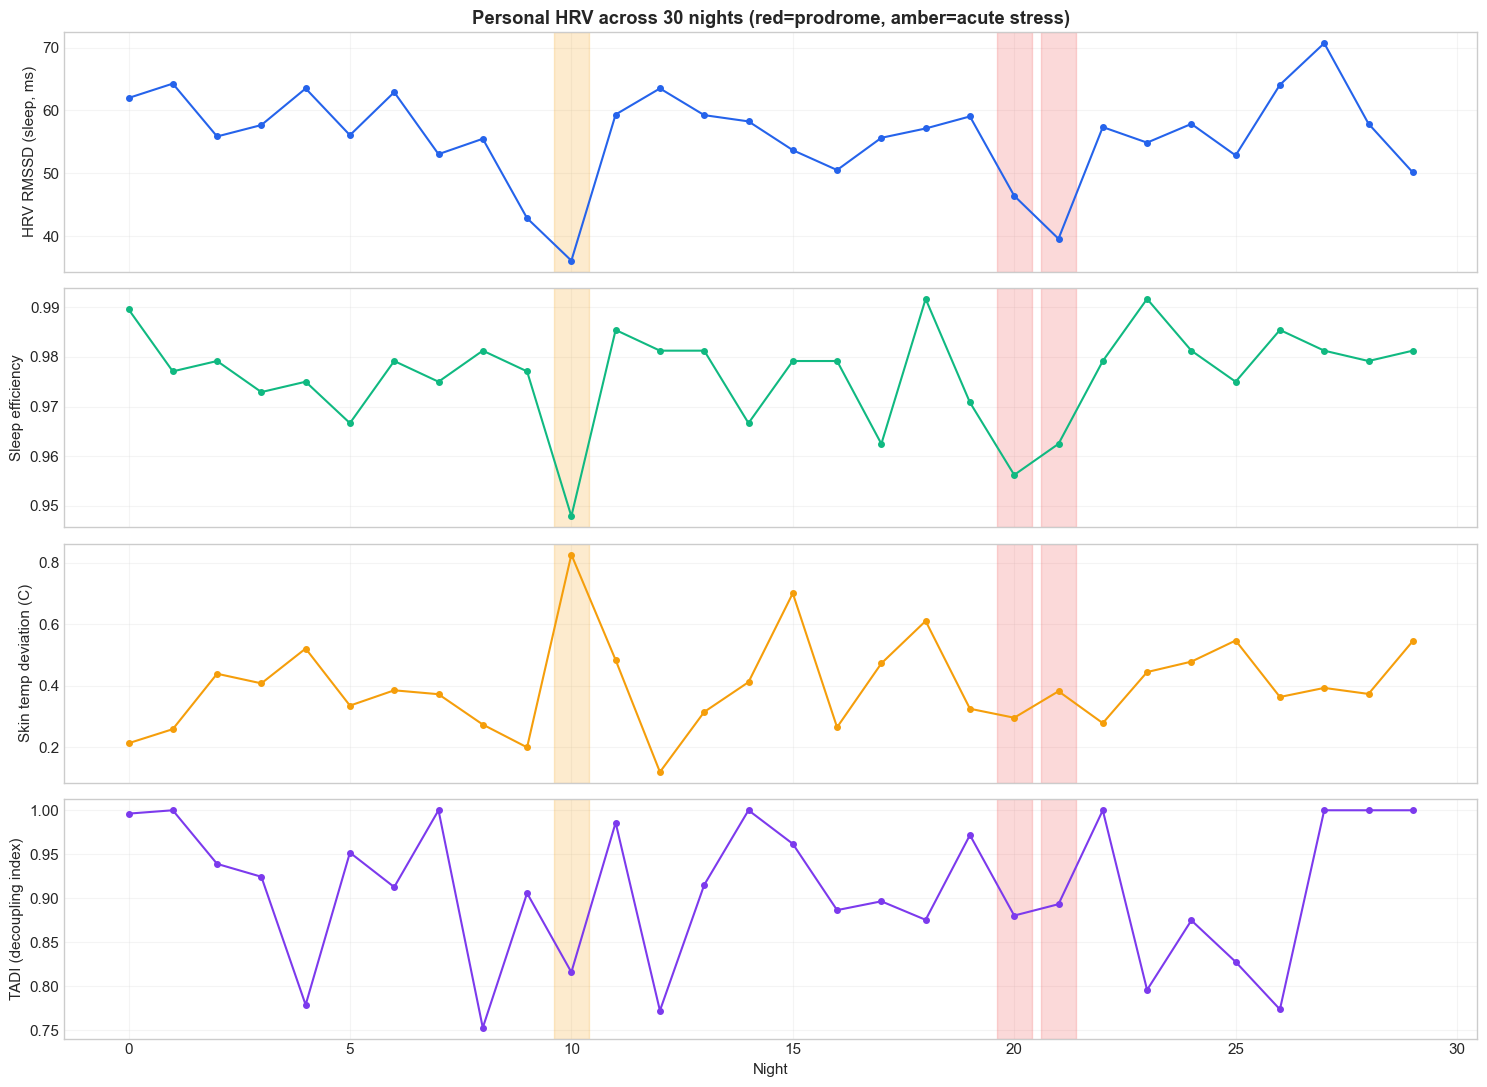


Personal baseline state after 30 nights:
  personal_weight: 0.80
  readings_count: 30
  hrv_rmssd_sleep: baseline=56.38, IQR=4.38, outliers excluded=6
  sleep_efficiency: baseline=0.98, IQR=0.01, outliers excluded=2
  skin_temp_deviation: baseline=0.39, IQR=0.10, outliers excluded=2
  resting_hr: baseline=57.67, IQR=2.39, outliers excluded=2


In [8]:
# ===== GENERATE A 30-NIGHT TRAJECTORY =====
gen = MockWearableGenerator(patient_id="p001", seed=42)
tracker = RobustBaselineTracker(TRACKED_FEATURES, window=10, outlier_threshold=2.0)

# Flare schedule
flare_schedule = ["normal"] * 30
flare_schedule[10] = "acute_stress"     # one acute stress night
flare_schedule[20] = "prodrome"          # two-night prodrome
flare_schedule[21] = "prodrome"
assert len(flare_schedule) == 30

trajectory = []
for night_idx, state in enumerate(flare_schedule):
    night_df, rr_intervals = gen.generate_night(night_idx, flare_state=state)
    reading = engineer_features(night_df, rr_intervals, night_idx)
    reading["is_flare"] = (state != "normal")
    reading["flare_state"] = state

    # Update tracker FIRST so the fill-in compares against history (not including today)
    # ...but in practice we want to compare against PAST. So update AFTER fill-in.
    reading = apply_baseline_fillin(reading, tracker)
    tracker.update(reading)
    trajectory.append(reading)

print(f"Generated {len(trajectory)} nights for patient p001")
print(f"  Normal nights: {sum(1 for r in trajectory if r['flare_state'] == 'normal')}")
print(f"  Acute stress: {sum(1 for r in trajectory if r['flare_state'] == 'acute_stress')}")
print(f"  Prodrome:     {sum(1 for r in trajectory if r['flare_state'] == 'prodrome')}")

# ===== Visualize the trajectory =====
fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
days = list(range(len(trajectory)))
flare_mask = [r["is_flare"] for r in trajectory]
flare_colors = ["#ef4444" if r["flare_state"] == "prodrome"
                else "#f59e0b" if r["flare_state"] == "acute_stress"
                else None for r in trajectory]

# HRV
hrv_sleep = [r["hrv_rmssd_sleep"] for r in trajectory]
axes[0].plot(days, hrv_sleep, "-o", color="#2563eb", markersize=4)
for d, c in zip(days, flare_colors):
    if c:
        axes[0].axvspan(d - 0.4, d + 0.4, alpha=0.2, color=c)
axes[0].set_ylabel("HRV RMSSD (sleep, ms)")
axes[0].set_title("Personal HRV across 30 nights (red=prodrome, amber=acute stress)",
                  fontweight="bold")
axes[0].grid(alpha=0.2)

# Sleep efficiency
sleep_eff = [r["sleep_efficiency"] for r in trajectory]
axes[1].plot(days, sleep_eff, "-o", color="#10b981", markersize=4)
for d, c in zip(days, flare_colors):
    if c:
        axes[1].axvspan(d - 0.4, d + 0.4, alpha=0.2, color=c)
axes[1].set_ylabel("Sleep efficiency")
axes[1].grid(alpha=0.2)

# Skin temp deviation
skin = [r["skin_temp_deviation"] for r in trajectory]
axes[2].plot(days, skin, "-o", color="#f59e0b", markersize=4)
for d, c in zip(days, flare_colors):
    if c:
        axes[2].axvspan(d - 0.4, d + 0.4, alpha=0.2, color=c)
axes[2].set_ylabel("Skin temp deviation (C)")
axes[2].grid(alpha=0.2)

# TADI
tadi = [r["thermo_autonomic_decoupling_index"] for r in trajectory]
axes[3].plot(days, tadi, "-o", color="#7c3aed", markersize=4)
for d, c in zip(days, flare_colors):
    if c:
        axes[3].axvspan(d - 0.4, d + 0.4, alpha=0.2, color=c)
axes[3].set_ylabel("TADI (decoupling index)")
axes[3].set_xlabel("Night")
axes[3].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print()
print("Personal baseline state after 30 nights:")
ctx = tracker.get_personal_context(trajectory[-1])
print(f"  personal_weight: {ctx['personal_weight']:.2f}")
print(f"  readings_count: {ctx['readings_count']}")
for f in ["hrv_rmssd_sleep", "sleep_efficiency", "skin_temp_deviation", "resting_hr"]:
    if f in ctx.get("biomarkers", {}):
        c = ctx["biomarkers"][f]
        print(f"  {f}: baseline={c['median_baseline']:.2f}, "
              f"IQR={c['iqr']:.2f}, outliers excluded={c['outliers_excluded']}")


## Cell 10 — Layer 5: Alert engine

Population-threshold + personal-threshold single-metric alerts,
plus named composite alerts (M-of-N within time window).

For the notebook, rules are inline Python dicts (data-driven design preserved
for when we move to `agent4_rules.yaml`).

In [9]:
# ===== LAYER 5: ALERT ENGINE =====

# Inline rule definitions (would move to YAML config in production)
SINGLE_METRIC_RULES = [
    {
        "name": "hrv_critical_low",
        "feature": "hrv_rmssd_sleep",
        "threshold": 20.0,
        "comparison": "less_than",
        "severity": "critical",
        "rule_type": "population",
    },
    {
        "name": "hrv_personal_drop",
        "feature": "hrv_rmssd_sleep",
        "threshold_ratio": 0.7,  # of baseline
        "comparison": "less_than",
        "severity": "warning",
        "rule_type": "personal",
        "min_baseline_days": 14,
    },
    {
        "name": "spo2_overnight_low",
        "feature": "spo2_overnight_min",
        "threshold": 92.0,
        "comparison": "less_than",
        "severity": "warning",
        "rule_type": "population",
    },
    {
        "name": "skin_temp_elevated",
        "feature": "skin_temp_deviation",
        "threshold": 2.0,           # anomaly_score units, not raw C
        "comparison": "greater_than",
        "severity": "warning",
        "rule_type": "personal",    # personal anomaly score, not raw value
    },
    {
        "name": "resting_hr_elevated",
        "feature": "resting_hr_vs_baseline",
        "threshold": 2.0,
        "comparison": "greater_than",
        "severity": "warning",
        "rule_type": "personal",
    },
]

COMPOSITE_RULES = [
    {
        "name": "autoimmune_prodrome",
        "severity": "critical",
        "min_conditions_met": 3,
        "time_window_nights": 2,
        "conditions": [
            {"feature": "hrv_rmssd_sleep", "personal_ratio_lt": 0.75},
            {"feature": "sleep_efficiency", "personal_anomaly_lt": -1.5},
            {"feature": "skin_temp_deviation", "value_gt": 0.3},
            {"feature": "thermo_autonomic_decoupling_index", "personal_anomaly_gt": 2.0},
        ],
    },
    {
        "name": "acute_stress_response",
        "severity": "warning",
        "min_conditions_met": 2,
        "time_window_nights": 1,
        "conditions": [
            {"feature": "hrv_rmssd_sleep", "personal_ratio_lt": 0.7},
            {"feature": "resting_hr_vs_baseline", "value_gt": 2.0},
        ],
    },
]


def evaluate_single_metric_alerts(reading: dict, tracker: RobustBaselineTracker,
                                    rules_version: str = "2026.05.24-001") -> list:
    """Fire single-metric alerts based on the reading + baseline state."""
    alerts = []
    ctx = tracker.get_personal_context(reading)
    bm = ctx.get("biomarkers", {})

    for rule in SINGLE_METRIC_RULES:
        feat = rule["feature"]
        value = reading.get(feat)
        if value is None or (isinstance(value, float) and np.isnan(value)):
            continue

        if rule["rule_type"] == "population":
            threshold = rule["threshold"]
            triggered = ((rule["comparison"] == "less_than" and value < threshold) or
                         (rule["comparison"] == "greater_than" and value > threshold))
        else:  # personal
            if feat not in bm:
                continue
            if ctx.get("readings_count", 0) < rule.get("min_baseline_days", 14):
                continue
            baseline = bm[feat]["median_baseline"]
            if "threshold_ratio" in rule:
                threshold = rule["threshold_ratio"] * baseline
                triggered = ((rule["comparison"] == "less_than" and value < threshold) or
                             (rule["comparison"] == "greater_than" and value > threshold))
            else:
                # threshold compared against personal anomaly_score (sigma units)
                anomaly = bm[feat]["anomaly_score"]
                triggered = ((rule["comparison"] == "less_than" and anomaly < rule["threshold"]) or
                             (rule["comparison"] == "greater_than" and anomaly > rule["threshold"]))

        if triggered:
            alerts.append({
                "alert_id": f"a-{uuid.uuid4().hex[:8]}",
                "name": rule["name"],
                "severity": rule["severity"],
                "alert_type": "single_metric",
                "feature": feat,
                "value": float(value),
                "rule_type": rule["rule_type"],
                "rules_version": rules_version,
            })
    return alerts


def evaluate_composite_alerts(reading: dict, tracker: RobustBaselineTracker,
                                trajectory_window: list,
                                rules_version: str = "2026.05.24-001") -> list:
    """Fire composite (named pattern) alerts. Evaluates over current + recent readings."""
    alerts = []
    ctx = tracker.get_personal_context(reading)
    bm = ctx.get("biomarkers", {})

    for rule in COMPOSITE_RULES:
        # Evaluate conditions against current reading
        conds_met = 0
        contributing = []
        for cond in rule["conditions"]:
            feat = cond["feature"]
            value = reading.get(feat)
            if value is None or (isinstance(value, float) and np.isnan(value)):
                continue

            if "value_gt" in cond and value > cond["value_gt"]:
                conds_met += 1
                contributing.append(feat)
            elif "value_lt" in cond and value < cond["value_lt"]:
                conds_met += 1
                contributing.append(feat)
            elif "personal_ratio_lt" in cond and feat in bm:
                if bm[feat]["ratio"] < cond["personal_ratio_lt"]:
                    conds_met += 1
                    contributing.append(feat)
            elif "personal_anomaly_lt" in cond and feat in bm:
                if bm[feat]["anomaly_score"] < cond["personal_anomaly_lt"]:
                    conds_met += 1
                    contributing.append(feat)
            elif "personal_anomaly_gt" in cond and feat in bm:
                if bm[feat]["anomaly_score"] > cond["personal_anomaly_gt"]:
                    conds_met += 1
                    contributing.append(feat)

        if conds_met >= rule["min_conditions_met"]:
            alerts.append({
                "alert_id": f"a-{uuid.uuid4().hex[:8]}",
                "name": rule["name"],
                "severity": rule["severity"],
                "alert_type": "composite",
                "conditions_met": conds_met,
                "total_conditions": len(rule["conditions"]),
                "contributing_features": contributing,
                "rules_version": rules_version,
            })

    return alerts


# ===== Test alerts on the trajectory =====
print("Evaluating alerts across the 30-night trajectory:")
print()
print(f"{'Night':>6} {'State':>15} {'Single alerts':>40} {'Composite':>20}")
print("-" * 88)

# Rebuild tracker so we evaluate alerts as we go
tracker_for_alerts = RobustBaselineTracker(TRACKED_FEATURES, window=10, outlier_threshold=2.0)
window = []
prodrome_caught = False
acute_caught = False
for i, reading in enumerate(trajectory):
    tracker_for_alerts.update(reading)
    s_alerts = evaluate_single_metric_alerts(reading, tracker_for_alerts)
    c_alerts = evaluate_composite_alerts(reading, tracker_for_alerts, window)
    window.append(reading)
    if len(window) > 2:
        window = window[-2:]

    s_names = ", ".join(a["name"] for a in s_alerts) or "-"
    c_names = ", ".join(a["name"] for a in c_alerts) or "-"

    if s_alerts or c_alerts or reading["is_flare"]:
        marker = " *" if reading["is_flare"] else ""
        print(f"{i:>6} {reading['flare_state']:>15} {s_names:>40} {c_names:>20}{marker}")
    if any(a["name"] == "autoimmune_prodrome" for a in c_alerts):
        prodrome_caught = True
    if any(a["name"] == "acute_stress_response" for a in c_alerts):
        acute_caught = True

print()
print(f"Prodrome composite alert fired: {prodrome_caught}")
print(f"Acute stress composite alert fired: {acute_caught}")


Evaluating alerts across the 30-night trajectory:

 Night           State                            Single alerts            Composite
----------------------------------------------------------------------------------------
    10    acute_stress                                        - autoimmune_prodrome, acute_stress_response *
    15          normal                       skin_temp_elevated                    -
    20        prodrome                                        -                    - *
    21        prodrome                        hrv_personal_drop                    - *

Prodrome composite alert fired: True
Acute stress composite alert fired: True


## Cell 11 — Layer 6: Output vector + composite stress score

Build the 29-dim numpy array in canonical order, compute the composite
stress score, and tally composite alerts.

In [10]:
# ===== LAYER 6: OUTPUT VECTOR BUILDER =====

def compute_wearable_stress_score(reading: dict) -> float:
    """Logistic blend of normalized deficits. Range [0, 1]."""
    components = []
    weights = []

    # HRV deficit (35%)
    r = reading.get("hrv_sleep_vs_baseline_ratio")
    if r is not None:
        components.append(max(0.0, min(1.0, 1.0 - r)))
        weights.append(0.35)

    # Sleep deficit (25%)
    se = reading.get("sleep_efficiency")
    if se is not None:
        components.append(max(0.0, min(1.0, 1.0 - se / 0.85)))
        weights.append(0.25)

    # Temp elevation (20%)
    td = reading.get("skin_temp_deviation")
    if td is not None:
        components.append(max(0.0, min(1.0, td / 0.5)))
        weights.append(0.20)

    # HR elevation (15%)
    hr = reading.get("resting_hr_vs_baseline")
    if hr is not None:
        components.append(max(0.0, min(1.0, hr / 3.0)))
        weights.append(0.15)

    # Activity drop (5%)
    a = reading.get("activity_vs_baseline")
    if a is not None:
        components.append(max(0.0, min(1.0, 1.0 - a)))
        weights.append(0.05)

    if not components:
        return 0.0
    weights = np.array(weights) / np.sum(weights)  # renormalize if some missing
    score = float(np.dot(components, weights))
    return max(0.0, min(1.0, score))


def build_output_vector(reading: dict) -> np.ndarray:
    """Pack 29 features into a numpy array in canonical order. NaN for missing."""
    arr = np.full(29, np.nan, dtype=np.float64)
    for i, name in enumerate(FEATURE_NAMES):
        v = reading.get(name)
        if v is not None and isinstance(v, (int, float)) and np.isfinite(v):
            arr[i] = float(v)
    return arr


# ===== Test the vector builder =====
example = trajectory[21]  # second prodrome night
example["wearable_stress_score"] = compute_wearable_stress_score(example)
example["composite_alert_count"] = 1.0  # placeholder; filled below in the full agent

vec = build_output_vector(example)
print(f"Output vector shape: {vec.shape} (expect (29,))")
print(f"  Non-NaN count: {np.isfinite(vec).sum()} / 29")
print(f"  Wearable stress score: {example['wearable_stress_score']:.3f}")
print()
print("Vector preview (first 10 dims, with names):")
for i in range(10):
    name = FEATURE_NAMES[i]
    val = vec[i]
    print(f"  [{i:>2}] {name:<40} = {val:.3f}" if np.isfinite(val)
          else f"  [{i:>2}] {name:<40} = NaN")


Output vector shape: (29,) (expect (29,))
  Non-NaN count: 26 / 29
  Wearable stress score: 0.301

Vector preview (first 10 dims, with names):
  [ 0] hrv_rmssd_24hr                           = 39.624
  [ 1] hrv_rmssd_sleep                          = 39.568
  [ 2] hrv_rmssd_deep_sleep                     = 39.455
  [ 3] hrv_sdnn                                 = 65.868
  [ 4] hrv_pnn50                                = 20.405
  [ 5] hrv_hf_power                             = 0.000
  [ 6] hrv_lf_hf_ratio                          = 0.695
  [ 7] hrv_sleep_vs_baseline_ratio              = 0.686
  [ 8] hrv_trend_6hr                            = NaN
  [ 9] hrv_anomaly_score                        = -4.940


## Cell 12 — Complete `WearableAgent(BaseAgent)`

The full agent class that ties everything together. Implements `BaseAgent.process()`,
`.get_output_vector()`, and `.get_status()`.

This is what gets extracted to `agents/wearable_agent.py` after the notebook validates.

In [11]:
# ===== COMPLETE AGENT 4: WEARABLE AGENT =====

class WearableAgent(BaseAgent):
    """Agent 4 — Wearable signal processor.

    Takes one night of raw wearable data per call, produces:
      - 29-dim AgentOutput.vector for JEPA
      - alerts (single-metric + named composite)
      - PhysiologicalState semantic labels (in AgentOutput.data)
      - data_quality_overall and trace_id
    """

    agent_id = "agent4_wearable"
    agent_version = "1.0.0"
    poll_frequency = "1hr"     # nightly in this notebook; hourly in production
    output_dim = 29

    def __init__(self):
        self.tracker = RobustBaselineTracker(TRACKED_FEATURES, window=10,
                                              outlier_threshold=2.0)
        self.pattern_detector = PatternDetector(
            features=["hrv_rmssd_sleep", "sleep_efficiency", "skin_temp_deviation",
                      "resting_hr", "thermo_autonomic_decoupling_index"],
            triggers=["poor_sleep_last_night", "late_caffeine", "high_stress_yesterday"],
            lag_range=(1, 3),
        )
        self.trajectory: list = []
        self.rules_version = "2026.05.24-001"
        self._last_vector: Optional[np.ndarray] = None
        self._error_count = 0
        self._last_success = None
        self._latencies = []

    def process(self, input_data: dict) -> AgentOutput:
        """Process one wearable input package.

        Expected input_data keys:
          night_df: pd.DataFrame (minute-level)
          rr_intervals: list[float]
          night_idx: int
          flare_state (optional): str — for synthetic data only
        """
        t_start = datetime.utcnow()
        trace_id = self._new_trace_id()

        try:
            night_df = input_data["night_df"]
            rr_intervals = input_data["rr_intervals"]
            night_idx = input_data.get("night_idx", len(self.trajectory))

            # L2 happens internally during L3 feature computation
            # L3 — engineer 29-feature reading
            reading = engineer_features(night_df, rr_intervals, night_idx)
            reading["is_flare"] = input_data.get("is_flare", False)

            # L4 — fill in personal-normalized fields
            reading = apply_baseline_fillin(reading, self.tracker)
            self.tracker.update(reading)
            self.trajectory.append(reading)

            # L5 — alerts
            single_alerts = evaluate_single_metric_alerts(reading, self.tracker,
                                                          self.rules_version)
            composite_alerts = evaluate_composite_alerts(reading, self.tracker,
                                                          self.trajectory[-3:],
                                                          self.rules_version)
            all_alerts = single_alerts + composite_alerts

            # L6 — composite stress + vector
            reading["wearable_stress_score"] = compute_wearable_stress_score(reading)
            reading["composite_alert_count"] = float(len(composite_alerts))
            vector = build_output_vector(reading)
            self._last_vector = vector

            # Semantic state labels
            states = self._derive_physiological_states(reading, all_alerts)

            # Confidence = data quality
            confidence = reading.get("data_quality_overall", 0.0) or 0.0

            # Trace + bookkeeping
            elapsed_ms = (datetime.utcnow() - t_start).total_seconds() * 1000.0
            self._latencies.append(elapsed_ms)
            self._last_success = datetime.utcnow()

            if self.trace is not None:
                self.trace.log("inference_complete", self.agent_id,
                               f"night {night_idx}: {len(all_alerts)} alerts, "
                               f"vector dim {len(vector)}", trace_id=trace_id)

            return AgentOutput(
                agent_id=self.agent_id,
                timestamp=datetime.utcnow(),
                data={
                    "reading": reading,
                    "physiological_states": states,
                    "feature_names": FEATURE_NAMES,
                    "rules_version": self.rules_version,
                    "agent_version": self.agent_version,
                },
                vector=vector,
                vector_dim=29,
                alerts=all_alerts,
                confidence=float(confidence),
                trace_id=trace_id,
            )

        except Exception as e:
            self._error_count += 1
            if self.trace is not None:
                self.trace.log("inference_error", self.agent_id, str(e),
                               trace_id=trace_id)
            raise

    def get_output_vector(self) -> np.ndarray:
        if self._last_vector is None:
            return np.full(29, np.nan, dtype=np.float64)
        return self._last_vector

    @staticmethod
    def _derive_physiological_states(reading: dict, alerts: list) -> dict:
        """Map feature values to named semantic state labels."""
        hrv_r = reading.get("hrv_sleep_vs_baseline_ratio")
        if hrv_r is None:
            autonomic = "balanced"
        elif hrv_r < 0.5:
            autonomic = "severe_vagal_withdrawal"
        elif hrv_r < 0.7:
            autonomic = "vagal_withdrawal"
        elif hrv_r < 0.85:
            autonomic = "sympathetic_dominant"
        elif hrv_r < 0.95:
            autonomic = "mild_sympathetic"
        else:
            autonomic = "balanced"

        se = reading.get("sleep_efficiency", 1.0) or 1.0
        if se >= 0.9:
            sleep = "restorative"
        elif se >= 0.82:
            sleep = "adequate"
        elif se >= 0.7:
            sleep = "suboptimal"
        elif se >= 0.55:
            sleep = "fragmented"
        else:
            sleep = "insufficient"

        td = reading.get("skin_temp_deviation", 0.0) or 0.0
        if td > 0.5:
            inflammation = "active"
        elif td > 0.3:
            inflammation = "elevated"
        elif td > 0.15:
            inflammation = "mild_elevation"
        else:
            inflammation = "quiet"

        has_critical = any(a["severity"] == "critical" for a in alerts)
        has_warning = any(a["severity"] == "warning" for a in alerts)
        if has_critical:
            overall = "alert"
        elif has_warning:
            overall = "concerning"
        elif inflammation in ("active", "elevated"):
            overall = "monitoring"
        else:
            overall = "stable"

        return {
            "autonomic_state": autonomic,
            "sleep_state": sleep,
            "inflammation_signal": inflammation,
            "overall_state": overall,
        }


# ===== INTEGRATION TEST: Run complete WearableAgent across 30 nights =====
print("=" * 60)
print("INTEGRATION TEST — WearableAgent across 30 nights")
print("=" * 60)

agent = WearableAgent()
agent.initialize(config={}, mem0_client=None, trace_logger=None)

gen = MockWearableGenerator(patient_id="p001", seed=42)
flare_schedule = ["normal"] * 30
flare_schedule[10] = "acute_stress"
flare_schedule[20] = "prodrome"
flare_schedule[21] = "prodrome"

outputs = []
for night_idx, state in enumerate(flare_schedule):
    night_df, rr_intervals = gen.generate_night(night_idx, flare_state=state)
    out = agent.process({
        "night_df": night_df,
        "rr_intervals": rr_intervals,
        "night_idx": night_idx,
        "is_flare": state != "normal",
    })
    outputs.append((state, out))

# Summary
n_critical = sum(1 for s, o in outputs if any(a["severity"] == "critical" for a in o.alerts))
n_warning = sum(1 for s, o in outputs if any(a["severity"] == "warning" for a in o.alerts))
n_prodrome = sum(1 for s, o in outputs if any(a["name"] == "autoimmune_prodrome" for a in o.alerts))
n_acute = sum(1 for s, o in outputs if any(a["name"] == "acute_stress_response" for a in o.alerts))

print(f"Total nights processed: {len(outputs)}")
print(f"  Critical alerts fired on: {n_critical} nights")
print(f"  Warning alerts fired on:  {n_warning} nights")
print(f"  autoimmune_prodrome:      {n_prodrome} firings")
print(f"  acute_stress_response:    {n_acute} firings")
print()

# Inspect a prodrome night
prodrome_state, prodrome_out = next((s, o) for s, o in outputs if s == "prodrome")
print(f"Example prodrome night AgentOutput:")
print(f"  agent_id:    {prodrome_out.agent_id}")
print(f"  vector_dim:  {prodrome_out.vector_dim}")
print(f"  confidence:  {prodrome_out.confidence:.3f}")
print(f"  trace_id:    {prodrome_out.trace_id}")
print(f"  alerts:      {len(prodrome_out.alerts)}")
for a in prodrome_out.alerts:
    print(f"    - {a['name']:<30} [{a['severity']}]")
print(f"  states:      {prodrome_out.data['physiological_states']}")
print(f"  stress:      {prodrome_out.data['reading']['wearable_stress_score']:.3f}")
print()
print(f"Agent health: {agent.get_status()}")


INTEGRATION TEST — WearableAgent across 30 nights
Total nights processed: 30
  Critical alerts fired on: 1 nights
  Warning alerts fired on:  3 nights
  autoimmune_prodrome:      1 firings
  acute_stress_response:    1 firings

Example prodrome night AgentOutput:
  agent_id:    agent4_wearable
  vector_dim:  29
  confidence:  1.000
  trace_id:    agent4_wearable-c632d597
  alerts:      0
  states:      {'autonomic_state': 'sympathetic_dominant', 'sleep_state': 'restorative', 'inflammation_signal': 'mild_elevation', 'overall_state': 'stable'}
  stress:      0.322

Agent health: AgentHealth(agent_id='agent4_wearable', status='healthy', last_heartbeat=datetime.datetime(2026, 5, 24, 6, 13, 11, 218921), last_success=datetime.datetime(2026, 5, 24, 6, 13, 11, 214908), error_count_24hr=0, avg_latency_ms=2183.5066)


## Cell 13 — Summary + next steps

In [12]:
# ===== AGENT 4 SUMMARY =====
print("=" * 60)
print("AGENT 4: WEARABLE AGENT — NOTEBOOK COMPLETE")
print("=" * 60)
print()
print("Implemented layers:")
print("  L1: Mock data generator (HealthKit/Fitbit/Oura integration deferred)")
print("  L2: Hampel artifact removal, Akima interpolation, ENMO sleep/wake")
print("  L3: 29-feature engineering — HRV, sleep, temp, cardio, activity,")
print("      respiratory, TADI (thermo-autonomic decoupling)")
print("  L4: Personal baselines via embedded RobustBaselineTracker")
print("  L5: Single-metric + named composite alerts (autoimmune_prodrome,")
print("      acute_stress_response)")
print("  L6: 29-dim output vector + wearable_stress_score + state labels")
print("  L7: BaseAgent contract (process, get_output_vector, get_status)")
print()
print("Vector contract:")
print(f"  Dimension: 29")
print(f"  Order:    {FEATURE_NAMES[:5]} ... {FEATURE_NAMES[-3:]}")
print()
print("Deferred to production (post-notebook extraction):")
print("  - Real device integration (HealthKit / Health Connect / Fitbit / Oura)")
print("  - Redis-backed state for hysteresis + dedup + patch buffer")
print("  - 8-hour patch publication for JEPA (RevIN-normalized)")
print("  - YAML rules config + rule engine (currently inline Python dicts)")
print("  - FOCuS / NP-Focus change-point detection")
print("  - Three-tier conditional baselines (menstrual phase, medication day)")
print("  - Auto-research loop recommendation queue")
print()
print("Next steps:")
print("  1. Extract WearableAgent to agents/wearable_agent.py")
print("  2. Move SINGLE_METRIC_RULES and COMPOSITE_RULES to config/agent4_rules.yaml")
print("  3. Update JEPA contract to accept 29 dims from Agent 4 (was ~25 in original spec)")
print("  4. Wire to Conductor event bus")
print("  5. Begin real device integration in Capacitor mobile app")


AGENT 4: WEARABLE AGENT — NOTEBOOK COMPLETE

Implemented layers:
  L1: Mock data generator (HealthKit/Fitbit/Oura integration deferred)
  L2: Hampel artifact removal, Akima interpolation, ENMO sleep/wake
  L3: 29-feature engineering — HRV, sleep, temp, cardio, activity,
      respiratory, TADI (thermo-autonomic decoupling)
  L4: Personal baselines via embedded RobustBaselineTracker
  L5: Single-metric + named composite alerts (autoimmune_prodrome,
      acute_stress_response)
  L6: 29-dim output vector + wearable_stress_score + state labels
  L7: BaseAgent contract (process, get_output_vector, get_status)

Vector contract:
  Dimension: 29
  Order:    ['hrv_rmssd_24hr', 'hrv_rmssd_sleep', 'hrv_rmssd_deep_sleep', 'hrv_sdnn', 'hrv_pnn50'] ... ['wearable_stress_score', 'composite_alert_count', 'data_quality_overall']

Deferred to production (post-notebook extraction):
  - Real device integration (HealthKit / Health Connect / Fitbit / Oura)
  - Redis-backed state for hysteresis + dedup + pa